# 🔬 Análise de Gaseificação a Plasma de Resíduos Sólidos Hospitalares no Google Colab

Este notebook do Google Colab foi desenvolvido para facilitar a análise de dados de gaseificação a plasma de resíduos sólidos hospitalares (RSU e RSS). Ele permite calcular a potência da tocha de plasma e plotar gráficos detalhados da composição de gases em função da temperatura, tudo em um ambiente interativo e baseado em nuvem.

## 🚀 Configuração do Ambiente

Execute a célula abaixo para instalar as bibliotecas Python necessárias para este notebook. O Google Colab já vem com muitas delas pré-instaladas, mas é uma boa prática garantir que todas as dependências estejam presentes e atualizadas.


In [ ]:
!pip install pandas matplotlib openpyxl --quiet


## 📂 Upload do Arquivo Excel e Seleção da Planilha

Por favor, execute a célula abaixo para fazer o upload do seu arquivo `Gaseificaçãoaplasma.xlsx`. Após o upload, o notebook listará as planilhas disponíveis e você poderá selecionar qual deseja analisar através de um menu interativo.

**Importante**: O seletor de planilha nas próximas células (`#@param`) não pode ser dinâmico no Colab. As opções listadas são exemplos. Certifique-se de que a planilha que você selecionar manualmente exista no seu arquivo Excel carregado.


In [ ]:
from google.colab import files
import pandas as pd
import io

# Faz o upload do arquivo
uploaded = files.upload()
excel_file_name = list(uploaded.keys())[0]
print(f"Arquivo '{excel_file_name}' carregado com sucesso.")

# Lê o arquivo para obter os nomes das planilhas
xls = pd.ExcelFile(io.BytesIO(uploaded[excel_file_name]))
available_sheets = xls.sheet_names

# Exibe as planilhas disponíveis para seleção interativa
print("Planilhas disponíveis no arquivo:")
for i, sheet in enumerate(available_sheets):
    print(f"  {i+1}. {sheet}")

# Variáveis globais para armazenar o conteúdo do arquivo e a lista de planilhas
# Isso permite que outras células acessem esses dados
global global_excel_file_content
global global_available_sheets
global_excel_file_content = uploaded[excel_file_name]
global_available_sheets = available_sheets


Saving Gaseificação a plasma.xlsx to Gaseificação a plasma.xlsx
Arquivo 'Gaseificação a plasma.xlsx' carregado com sucesso.
Planilhas disponíveis no arquivo:
  1. GIl_H2O_Vol
  2. GIL_H2O_wt
  3. Plan26
  4. GIL_O2_Vol
  5. GIL_O2_wt
  6. GIL_pyr_vol
  7. GIL_pyr_wt
  8. Outros_pyr_vol
  9. Outros_pyr_wt
  10. Enf_H2O_vol
  11. Enf_H2O_wt
  12. Enf_O2_vol
  13. Enf_O2_wt
  14. Enf_pyr_vol
  15. Enf_pyr_wt
  16. CC_H2O_vol
  17. CC_H2O_wt
  18. CC_O2_vol
  19. CC_O2_wt
  20. CC_pyr_vol
  21. CC_pyr_wt


## 📊 Análise de Energia e Entalpia

Esta seção calcula a potência da tocha ($E_{tocha}$) e plota-a em função da temperatura. Utilize o seletor de planilha abaixo para escolher qual conjunto de dados analisar.



Processando as planilhas: GIl_H2O_Vol e GIL_O2_Vol...


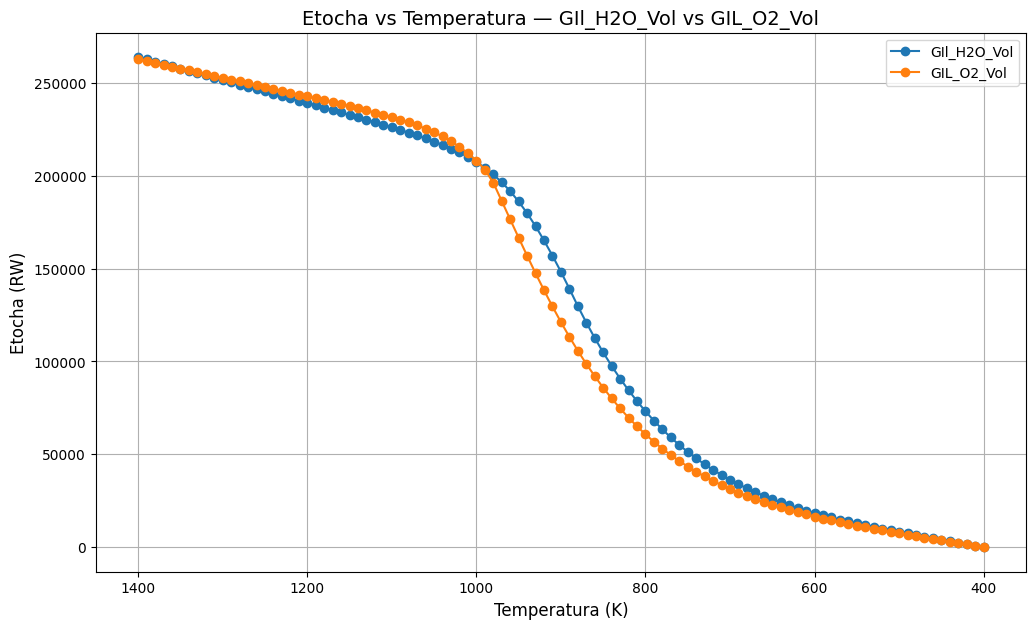

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import io
import numpy as np

#@title Selecione as Planilhas para Comparar (primeira = H2O, segunda = O2)
sheet_names_compare = ["GIl_H2O_Vol", "GIL_O2_Vol"]  #@param {type:"raw"}
eta_tocha = 0.95  # eficiência usada no cálculo de Etocha
invert_temperature_axis = True  #@param {type:"boolean"}  # True = eixo X (temperatura) vai aparecer invertido
header_row = 1  # linha de cabeçalho usada no Excel (igual ao que você tinha)

def read_and_prepare(df_bytes, sheet_name, header_row=1):
    """Lê planilha, valida colunas e calcula Etocha (com fallback de U em 400K via interpolação)."""
    try:
        df = pd.read_excel(io.BytesIO(df_bytes), sheet_name=sheet_name, header=header_row)
    except Exception as e:
        raise RuntimeError(f"Erro ao ler a planilha '{sheet_name}': {e}")

    # limpeza básica
    df.columns = df.columns.astype(str).str.strip()
    required = ["T", "U", "M"]
    if not all(col in df.columns for col in required):
        missing = [c for c in required if c not in df.columns]
        raise RuntimeError(f"Planilha '{sheet_name}' faltando colunas obrigatórias: {missing}")

    # garantir numerics
    df["T"] = pd.to_numeric(df["T"], errors="coerce")
    df["U"] = pd.to_numeric(df["U"], errors="coerce")
    df["M"] = pd.to_numeric(df["M"], errors="coerce")
    df = df.dropna(subset=["T"])  # remove linhas sem temperatura

    # ordenar por T asc para interpolação segura
    df = df.sort_values("T").reset_index(drop=True)

    # tentar obter U em T=400K; se não houver 400 exato, interpolar
    if (df["T"] == 400).any():
        u_400 = df.loc[df["T"] == 400, "U"].iloc[0]
    else:
        # precisa de ao menos 2 pontos para interpolar
        if df["T"].count() < 2:
            raise RuntimeError(f"Planilha '{sheet_name}' não tem pontos suficientes para interpolar U em 400K.")
        # interpolação numpy (funciona mesmo que 400 esteja fora do intervalo)
        u_400 = float(np.interp(400, df["T"].to_numpy(), df["U"].to_numpy()))

    # cálculo de DeltaH e Etocha
    df["DeltaH"] = df["U"] - u_400
    df["Etocha"] = (df["M"] * df["DeltaH"]) / eta_tocha

    return df

def generate_energy_plots_two_sheets(excel_file_content, sheet_names, eta_tocha=0.95, invert_temperature_axis=True):
    if len(sheet_names) != 2:
        raise ValueError("Forneça exatamente duas planilhas: [planilha_H2O, planilha_O2].")

    labels = sheet_names
    colors = ["tab:blue", "tab:orange"]
    fig, ax = plt.subplots(figsize=(12,7))

    for sheet, label, color in zip(sheet_names, labels, colors):
        try:
            df = read_and_prepare(excel_file_content, sheet, header_row=header_row)
        except Exception as e:
            print(e)
            return

        x = df["T"]
        y = df["Etocha"]
        ax.plot(x, y, marker="o", linestyle="-", label=label, color=color)

    ax.set_xlabel("Temperatura (K)", fontsize=12)
    ax.set_ylabel("Etocha (RW)", fontsize=12)
    ax.set_title(f"Etocha vs Temperatura — {labels[0]} vs {labels[1]}", fontsize=14)
    ax.grid(True)
    ax.legend()

    if invert_temperature_axis:
        ax.invert_xaxis()

    plt.show()


# Execução
print(f"\nProcessando as planilhas: {sheet_names_compare[0]} e {sheet_names_compare[1]}...")
if 'global_excel_file_content' in globals():
    try:
        generate_energy_plots_two_sheets(global_excel_file_content, sheet_names_compare, eta_tocha=eta_tocha, invert_temperature_axis=invert_temperature_axis)
    except Exception as e:
        print("Erro ao gerar os gráficos:", e)
else:
    print("Erro: O arquivo Excel não foi carregado. Por favor, execute a célula de upload primeiro.")

## 🧪 Análise de Composição de Gases

Esta seção foca na análise química dos produtos gerados no processo, plotando a composição em massa (%WT) e em volume (%Vol) de gases como H2 e CO em função da temperatura. Utilize o seletor de planilha abaixo para escolher qual conjunto de dados analisar.



Processando as planilhas: ['GIL_H2O_wt', 'GIL_O2_wt']...


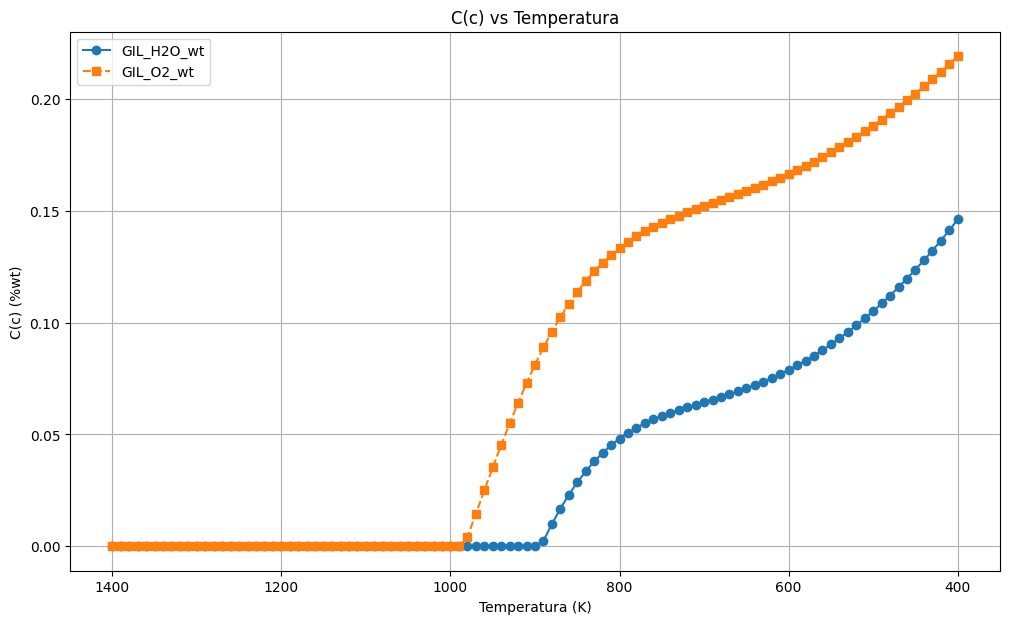

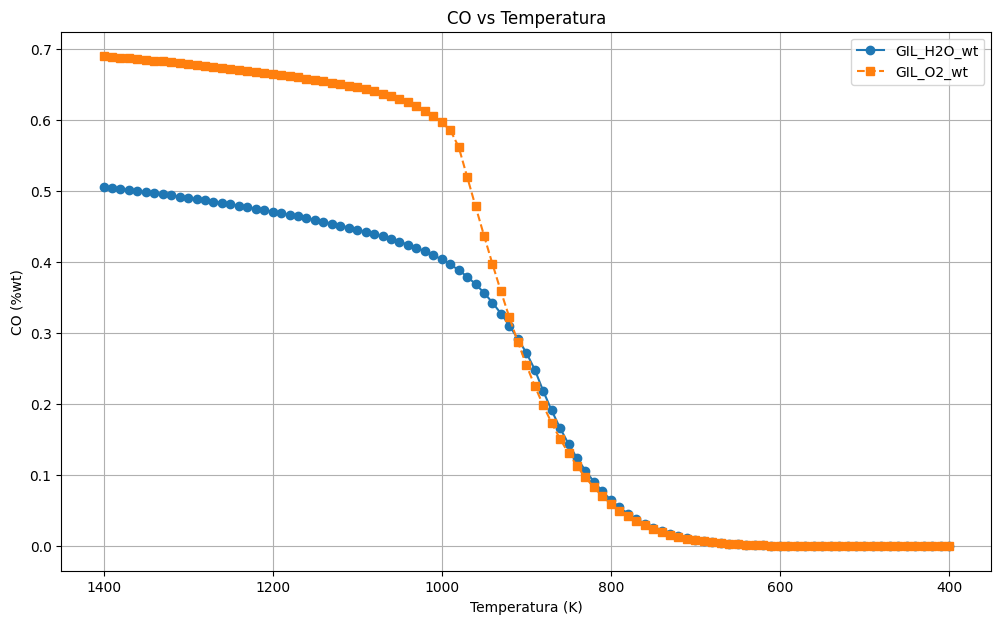

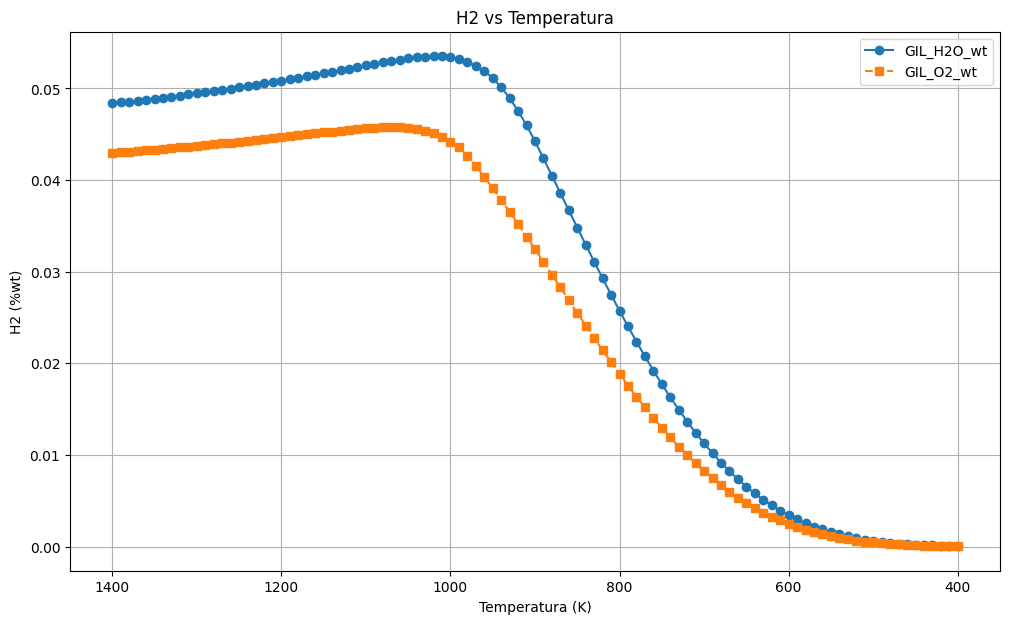

/tmp/ipykernel_1323/1947463543.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20')


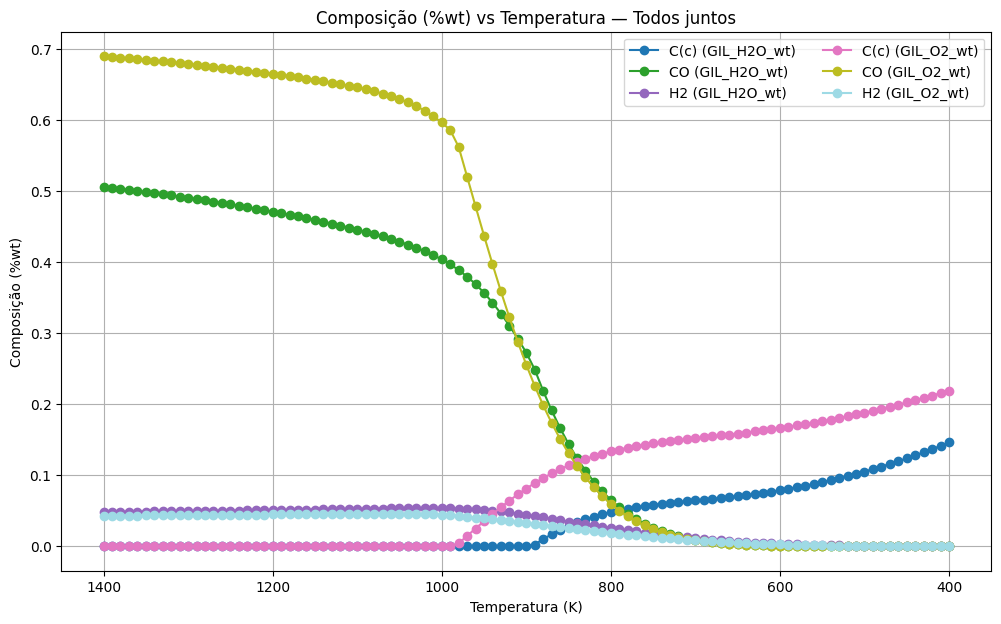

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import io
import numpy as np

#@title Selecione as Planilhas para Análise de Composição
sheet_names_compare = ["GIL_H2O_wt", "GIL_O2_wt"]  #@param {type:"raw"}

invert_temperature_axis = True  #@param {type:"boolean"}

species = ["C(c)", "CO", "H2"]

def read_sheet(excel_bytes, sheet_name):
    try:
        df = pd.read_excel(io.BytesIO(excel_bytes), sheet_name=sheet_name, header=1)
    except Exception as e:
        raise RuntimeError(f"Erro ao ler a planilha '{sheet_name}': {e}")

    df.columns = df.columns.str.strip()

    if "T" not in df.columns:
        raise RuntimeError(f"A planilha '{sheet_name}' não possui coluna 'T'.")

    df["T"] = pd.to_numeric(df["T"], errors="coerce")
    df = df.dropna(subset=["T"])
    df = df.sort_values("T").reset_index(drop=True)

    return df


def plot_single_species(df1, df2, sheet1, sheet2, specie):

    if specie not in df1.columns and specie not in df2.columns:
        print(f"Aviso: coluna '{specie}' não encontrada em nenhuma das duas planilhas.")
        print("\n")
        return

    plt.figure(figsize=(12,7))

    if specie in df1.columns:
        plt.plot(df1["T"], df1[specie], marker="o", linestyle="-", label=f"{sheet1}")

    if specie in df2.columns:
        plt.plot(df2["T"], df2[specie], marker="s", linestyle="--", label=f"{sheet2}")

    plt.title(f"{specie} vs Temperatura")
    plt.xlabel("Temperatura (K)")
    plt.ylabel(f"{specie} (%wt)")
    plt.legend()
    plt.grid(True)

    if invert_temperature_axis:
        plt.gca().invert_xaxis()

    plt.show()
    # pequeno espaço entre "tabelas"
    print("\n")


def plot_all_species_unique_colors(df1, df2, sheet1, sheet2):
    """
    Plota todas as espécies juntas; cada traço (espécie+planilha) tem sua cor única.
    """

    # construir lista de traços disponíveis (x, y, label)
    traces = []
    for sheet_label, df in [(sheet1, df1), (sheet2, df2)]:
        for specie in species:
            if specie in df.columns:
                traces.append((df["T"], df[specie], f"{specie} ({sheet_label})"))

    if not traces:
        print("Aviso: nenhuma das colunas das espécies foi encontrada em ambas as planilhas. Gráfico conjunto não será gerado.")
        print("\n")
        return

    plt.figure(figsize=(12,7))

    # paleta dinâmica (tab20 tem boa variedade)
    cmap = plt.cm.get_cmap('tab20')
    n = len(traces)
    colors = [cmap(i / max(1, n-1)) for i in range(n)]

    for (x, y, label), color in zip(traces, colors):
        plt.plot(x, y, marker="o", linestyle="-", label=label, color=color)

    plt.title("Composição (%wt) vs Temperatura — Todos juntos")
    plt.xlabel("Temperatura (K)")
    plt.ylabel("Composição (%wt)")
    plt.legend(ncol=2)
    plt.grid(True)

    if invert_temperature_axis:
        plt.gca().invert_xaxis()

    plt.show()
    print("\n")


def generate_composition_plots(excel_file_content, sheet_names):

    if len(sheet_names) != 2:
        print("Erro: forneça exatamente duas planilhas.")
        return

    sheet1, sheet2 = sheet_names

    try:
        df1 = read_sheet(excel_file_content, sheet1)
        df2 = read_sheet(excel_file_content, sheet2)
    except Exception as e:
        print(e)
        return

    # gráficos individuais (um por espécie)
    for specie in species:
        plot_single_species(df1, df2, sheet1, sheet2, specie)

    # gráfico conjunto com cores únicas por traço
    plot_all_species_unique_colors(df1, df2, sheet1, sheet2)


print(f"\nProcessando as planilhas: {sheet_names_compare}...")

if 'global_excel_file_content' in globals():
    generate_composition_plots(global_excel_file_content, sheet_names_compare)
else:
    print("Erro: O arquivo Excel não foi carregado. Execute a célula de upload primeiro.")

## 🧪 Metodologia de Cálculo

Os scripts aplicam as seguintes fórmulas e conceitos:

*   **Variação de Entalpia ($\Delta H$)**: Calculada como a diferença entre a entalpia ($U$) em uma dada temperatura ($U_i$) e a entalpia na temperatura de $400K$ ($U_{400}$). A coluna `U` do Excel é interpretada como Entalpia.
    $$ \Delta H = U_i - U_{400} $$

*   **Potência da Tocha ($E_{tocha}$)**: Calculada utilizando a vazão mássica ($M_{RSS}$), a variação de entalpia ($\Delta H$) e o rendimento da tocha ($\eta_{tocha} = 0.95$). A vazão mássica é extraída da coluna `M` do Excel.
    $$ E_{tocha} = \frac{M_{RSS} \cdot \Delta H}{\eta_{tocha}} $$

*   **Composição em Volume (%Vol)**: Os valores das colunas `H2` e `CO` são multiplicados por 100 para expressar a porcentagem em volume nos gráficos.

## 🤝 Créditos

Desenvolvido com 💙 por Manus AI para sua iniciação científica. Sucesso em sua pesquisa!
